# Fine-Tuning GPT-4.1 for Action Recognition in Video Clips
This Solution Accelerator demonstrates how to use Azure OpenAI GPT-4.1 vision fine-tuning to improve the model's performance in detecting human activities in video clips. The project utilizes the [UCF101 - Action Recognition](https://www.kaggle.com/datasets/matthewjansen/ucf101-action-recognition) dataset from Kaggle, a comprehensive video dataset featuring 101 distinct human action categories such as "playing guitar," "surfing," and "knitting." It contains 13,320 video clips, each labeled with a single action category.

Below are examples of video frames representing 8 of the 101 classes in the dataset:

<img src="frame-samples.png" alt="Frame Samples" width="1000">

__Acknowledgements:__

- Dataset: https://www.crcv.ucf.edu/research/data-sets/ucf101/
- Citation: https://arxiv.org/abs/1212.0402

This Solution Accelerator provides reusable code to help you apply vision fine-tuning for video analysis in various use cases.

> **Note:** By default, the Fine-Tuning API rejects images containing people and faces for AI safety reasons.
You can apply to opt out of this limitation by submitting a request here: https://customervoice.microsoft.com/Pages/ResponsePage.aspx.
Make sure to select the Modified Content Filtering option for Inferencing and Fine Tuning in question 14.

__Content:__

1. Retrieve dataset and specify scope
2. Prepare dataset for fine-tuning
3. Configure and start fine-tuning job
4. Deploy fine-tuned model
5. Test inference
6. Base versus fine-tuned model evaluation

## Setup

In [1]:
import json
import os
import time
from importlib.metadata import version as package_version
from io import StringIO
from typing import Dict, List

import kagglehub
import matplotlib
matplotlib.use("Agg")
import pandas as pd
from azure.ai.projects import AIProjectClient
from azure.core.exceptions import ResourceNotFoundError
from azure.identity import DefaultAzureCredential
from dotenv import load_dotenv
from sklearn.metrics import classification_report
from tqdm import tqdm

%config InlineBackend.figure_format = 'retina'

from VideoFTTools import DatasetHelper, VideoExtractor, VideoAnalyzer, Evaluator
from VideoFTTools import upload_frame_to_blob_as_jpeg, date_sorted_df


In [2]:
# Foundry SDK 2.x project authentication; no API keys or account endpoints.
load_dotenv()
project_endpoint = os.environ["AZURE_AI_PROJECT_ENDPOINT"]
credential = DefaultAzureCredential()
project_client = AIProjectClient(
    endpoint=project_endpoint,
    credential=credential,
)
client = project_client.get_openai_client()

# Central variables
project_name, version = "action-recognition-global-vision", "20261002"
ft_deployment = f"{project_name}-{version}-ft"
base_deployment = f"{project_name}-{version}-base"
base_model = "gpt-4.1-2025-04-14"

# A compact, stratified run keeps the demo economical while exercising the workflow.
top_n_classes = 3
train_samples_per_class = 12
val_samples_per_class = 4
test_samples_per_class = 5
no_frames = 3
random_seed = 0

# Keep downloaded and generated data in this demo directory.
os.environ["KAGGLEHUB_CACHE"] = os.path.join(os.getcwd(), ".kagglehub")

container_name = "frames"
connection_string = None
bold_start, bold_end = '\033[1m', '\033[0m'
run_started_at = pd.Timestamp.now("UTC").isoformat()
job_status_history = []
deployment_status_history = []

print({
    "project_endpoint": project_endpoint,
    "azure_ai_projects": package_version("azure-ai-projects"),
    "authentication": "DefaultAzureCredential",
})


{'project_endpoint': 'https://koreacentral-prakharg-demo-2026.services.ai.azure.com/api/projects/koreacentral-prakharg-demo-2026', 'azure_ai_projects': '2.7.0', 'authentication': 'DefaultAzureCredential'}


## Retrieve dataset and specify scope

The dataset presents diverse viewpoints, scales, camera motions, and lighting conditions, making it a challenging resource for action recognition tasks. It includes five categories of 101 action classes:
- Human-Object Interaction
- Body-Motion Only
- Human-Human Interaction
- Playing Musical Instruments
- Sports

This dataset is widely used as a benchmark in computer vision for training and evaluating action recognition models.  
**Note**: Please make sure that your Kaggle credentials are provided in the `.env` file.

In [3]:
# Download latest version from Kaggle. 
dataset_path = kagglehub.dataset_download("matthewjansen/ucf101-action-recognition")

print("Path to dataset files:", dataset_path)
os.listdir(dataset_path)

Path to dataset files: C:\Data\AIP\fine-tuning\Demos\Video_FT_Action_Recognition\.kagglehub\datasets\matthewjansen\ucf101-action-recognition\versions\4


['test', 'test.csv', 'train', 'train.csv', 'val', 'val.csv']

In [4]:
# retrieve local data
train_csv = os.path.join(dataset_path, "train.csv")
orig_train_df = pd.read_csv(train_csv)

val_csv = os.path.join(dataset_path, "val.csv")
orig_val_df = pd.read_csv(val_csv)

test_csv = os.path.join(dataset_path, "test.csv")
orig_test_df = pd.read_csv(test_csv)

# Remove leading slash if present. This step is specific to the action-recognition dataset
orig_train_df['clip_path'] = orig_train_df['clip_path'].str.lstrip('/')  
orig_val_df['clip_path'] = orig_val_df['clip_path'].str.lstrip('/')  
orig_test_df['clip_path'] = orig_test_df['clip_path'].str.lstrip('/')  

dataset_helper = DatasetHelper()
dataset_helper.plot_label_counts(orig_train_df, 'Original training dataset')

C:\Data\AIP\fine-tuning\Demos\Video_FT_Action_Recognition\VideoFTTools.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


We are reducing the dataset complexity and size in two ways for quick development iterations:

1. Reduce number of dataset classes
2. Reduce train, val, and test splits to specified number of observations

Feel free to adjust the number of classes and instances for your own experiments.

In [5]:
top_classes = orig_train_df['label'].value_counts().index[:top_n_classes]

def stratified_sample(df, samples_per_class):
    scoped = df[df['label'].isin(top_classes)]
    return (
        scoped.groupby('label', group_keys=False)
        .sample(n=samples_per_class, random_state=random_seed)
        .reset_index(drop=True)
    )

train_df = stratified_sample(orig_train_df, train_samples_per_class)
val_df = stratified_sample(orig_val_df, val_samples_per_class)
test_df = stratified_sample(orig_test_df, test_samples_per_class)

dataset_helper.plot_label_counts(train_df, 'Reduced training dataset')
dataset_helper.plot_label_counts(val_df, 'Reduced validation dataset')
dataset_helper.plot_label_counts(test_df, 'Reduced test dataset')
print({
    "classes": list(top_classes),
    "train": len(train_df),
    "validation": len(val_df),
    "test": len(test_df),
    "frames_per_video": no_frames,
})


{'classes': ['Basketball', 'CricketShot', 'TennisSwing'], 'train': 36, 'validation': 12, 'test': 15, 'frames_per_video': 3}


## Prepare dataset for fine-tuning
Language models like GPT-4.1 are not capable of processing video files directly. Instead, we need to extract individual frames as images to send to the model. For instance, a short 20-second video recorded at 25 fps could contain up to 500 frames, making it computationally expensive to process all of them. To address this, we adopt a frame sampling strategy.

Frame sampling strategies reduce computational complexity and can be tailored to specific use cases. Common strategies include:

- **Sample at specified intervals**: Extract frames at regular intervals (e.g., every 0.25 seconds).
- **Sample a fixed number of frames**: Select a specified number of frames evenly distributed across the video duration.
- **Scene-based sampling**: Identify distinct scenes in the video and sample frames from each scene.
- **Drop similar frames**: Remove redundant frames that contain minimal variation.

These strategies can also be combined to meet more complex requirements.

To begin, we examine the durations of the videos in the training dataset using the `DatasetHelper.plot_video_duration_histogram()` method. This analysis provides insights into the distribution of video lengths, helping to inform our sampling approach.


In [6]:
dataset_helper.plot_video_duration_histogram(train_df, dataset_path)

C:\Data\AIP\fine-tuning\Demos\Video_FT_Action_Recognition\VideoFTTools.py:86: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()



The `VideoExtractor.extract_n_video_frames(n)` method extracts `n` frames from a video file, distributing them evenly across the video's duration. Additionally, it appends a timestamp strip to each frame, providing the model with temporal context to understand the sequence and timing of events in the video.


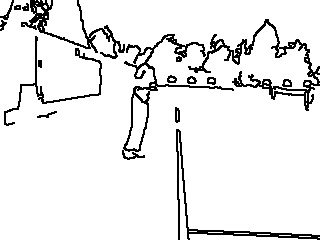
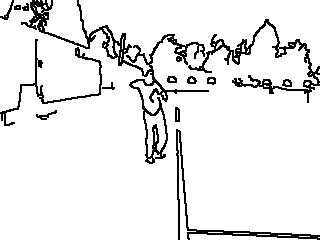
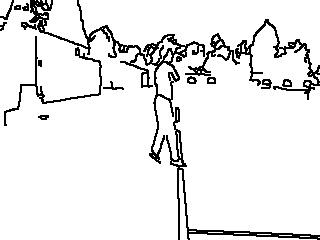

In [7]:
# Pick a random video and preview privacy-preserving motion/edge frames.
video_path = os.path.join(
    dataset_path,
    train_df.sample(n=1, random_state=random_seed)['clip_path'].iloc[0],
)
video_extractor = VideoExtractor(video_path, privacy_preserving=True)
frames = video_extractor.extract_n_video_frames(n=no_frames)
video_extractor.display_frames(frames, height=180)


Since the videos in our dataset are quite short and most of them consist of just one scene, we decide to sample only 5 frames per video.

Fine-tuning for video frames is possible with JSONL dataset files similar to the process of sending images as input to the chat completion API.
Images can be provided as HTTP URLs or data URLs containing base64-encoded images.

The next cells are for illustration purposes only (no need to execute).

_Example of video frames provided as **URLs**:_

In [8]:
{
    "messages": [
        {
            "role": "system",
            "content": "You are an AI that identifies human activities in video frames. Use the provided frames to recognize one activity from this list: ['Basketball', 'CricketShot', 'TennisSwing', 'PlayingGuitar', 'ShavingBeard']. Respond with a JSON object: {\"activity\": \"Activity name\"}."
        },
        {
            "role": "user",
            "content": "These are the video frames for activity identification."
        },
        {
            "role": "user",
            "content": [
                {"type": "image_url", "image_url": {"url": "https://example.com/frames/shavingbeard/frame1.jpg"}},
                {"type": "image_url", "image_url": {"url": "https://example.com/frames/shavingbeard/frame2.jpg"}},
                {"type": "image_url", "image_url": {"url": "https://example.com/frames/shavingbeard/frame3.jpg"}}
            ]
        },
        {
            "role": "assistant",
            "content": "{\"activity\": \"ShavingBeard\"}"
        }
    ]
}

{'messages': [{'role': 'system',
   'content': 'You are an AI that identifies human activities in video frames. Use the provided frames to recognize one activity from this list: [\'Basketball\', \'CricketShot\', \'TennisSwing\', \'PlayingGuitar\', \'ShavingBeard\']. Respond with a JSON object: {"activity": "Activity name"}.'},
  {'role': 'user',
   'content': 'These are the video frames for activity identification.'},
  {'role': 'user',
   'content': [{'type': 'image_url',
     'image_url': {'url': 'https://example.com/frames/shavingbeard/frame1.jpg'}},
    {'type': 'image_url',
     'image_url': {'url': 'https://example.com/frames/shavingbeard/frame2.jpg'}},
    {'type': 'image_url',
     'image_url': {'url': 'https://example.com/frames/shavingbeard/frame3.jpg'}}]},
  {'role': 'assistant', 'content': '{"activity": "ShavingBeard"}'}]}

_Example of video frames provided as **base64 encoded images**:_

In [9]:
{
    "messages": [
        {
            "role": "system",
            "content": "You are an AI that identifies human activities in video frames. Use the provided frames to recognize one activity from this list: ['Basketball', 'CricketShot', 'TennisSwing', 'PlayingGuitar', 'ShavingBeard']. Respond with a JSON object: {\"activity\": \"Activity name\"}."
        },
        {
            "role": "user",
            "content": "These are the video frames for activity identification."
        },
        {
            "role": "user",
            "content": [
                {"type": "image_base64", "image_data": "data:image/jpg;base64,/9j/4AAQ..."},
                {"type": "image_base64", "image_data": "data:image/jpg;base64,/9j/4AAQ..."},
                {"type": "image_base64", "image_data": "data:image/jpg;base64,/9j/4AAQ..."}
            ]
        },
        {
            "role": "assistant",
            "content": "{\"activity\": \"ShavingBeard\"}"
        }
    ]
}

{'messages': [{'role': 'system',
   'content': 'You are an AI that identifies human activities in video frames. Use the provided frames to recognize one activity from this list: [\'Basketball\', \'CricketShot\', \'TennisSwing\', \'PlayingGuitar\', \'ShavingBeard\']. Respond with a JSON object: {"activity": "Activity name"}.'},
  {'role': 'user',
   'content': 'These are the video frames for activity identification.'},
  {'role': 'user',
   'content': [{'type': 'image_base64',
     'image_data': 'data:image/jpg;base64,/9j/4AAQ...'},
    {'type': 'image_base64',
     'image_data': 'data:image/jpg;base64,/9j/4AAQ...'},
    {'type': 'image_base64',
     'image_data': 'data:image/jpg;base64,/9j/4AAQ...'}]},
  {'role': 'assistant', 'content': '{"activity": "ShavingBeard"}'}]}

In [10]:
top_classes_str = ', '.join(top_classes)

system_message = f"""You are an expert in identifying human activities in video clips.
You are provided with a time-ordered series of privacy-preserving edge frames from a video.
Use the shapes, objects, poses, and motion progression across the ordered frames to identify
one activity from this list:
{top_classes_str}

Provide the result as a valid JSON object in the exact format below:
{{
    "activity": "The identified activity from the provided list, spelled exactly as given."
}}
"""


The below function generates local JSONL dataset files in the format required for GPT-4.1 vision fine-tuning. The files are uploaded to the Azure OpenAI Fine-tuning API later. Use the `image_source` parameter to specify how to provide the video frames:
- `base64`: Frames will be included in the JSONL file directly as base64-encoded strings. 
- `url`: Frames will be uploaded to an Azure Storage Blob container that you provide and an URL pointing to the video frames will be generated.

In [11]:
# defining the function here so that it can be adjusted to other dataset formats directly
def generate_ft_dataset(
    df, 
    frames_per_video: int = 5, 
    image_source: str = 'base64',
    dataset_path: str = dataset_path,
    system_message: str = system_message,
    container_name: str = container_name,
    connection_string: str = connection_string
) -> List[Dict]:
    """
    Generates a dataset from video clips by extracting frames and including their metadata.

    Args:
        df: A pandas DataFrame containing video metadata. Must include `clip_path` and `label` columns.
        frames_per_video (int): Number of frames to extract from each video. Default is 5.
        image_source (str): Specifies the source of the image data ('base64' or 'url').
        dataset_path (str): Path to the dataset containing video files. Default is './datasets'.
        system_message (str): A system message to initialize the dataset entry. Default is "Process video frames".
        container_name (str): Azure Blob Storage container name for uploading images. Default is "frames".
        connection_string (str): Azure Blob Storage connection string.

    Returns:
        List[Dict]: A list of dataset entries, each containing the frames and associated labels.

    Raises:
        ValueError: If `image_source` is not 'base64' or 'url'.
        RuntimeError: If frame extraction or Azure upload fails.
    """
    dataset = []

    for index, video in tqdm(df.iterrows(), total=df.shape[0], desc="Processing videos"):
        clip_path = video.get('clip_path')
        label = video.get('label')
        
        if not clip_path or not label:
            print(f"Skipping entry at index {index}: Missing 'clip_path' or 'label'")
            continue

        full_path = os.path.join(dataset_path, clip_path)

        # Extract video frames
        video_extractor = VideoExtractor(uri=full_path, privacy_preserving=True)
        try:
            frames = video_extractor.extract_n_video_frames(n=frames_per_video)
        except Exception as e:
            print(f"Failed to extract frames for video {clip_path}: {e}")
            continue

        # Initialize message
        message = [
            {"role": "system", "content": system_message},
            {"role": "user", "content": "These are the frames from the video."}
        ]

        if image_source == 'base64':
            try:
                frames_list = [entry['frame_base64'] for entry in frames]
                message.append({"role": "user", "content": [
                    *map(lambda x: {"type": "image_url",
                                    "image_url": {"url": f'data:image/jpg;base64,{x}'}}, frames_list),
                ]})
            except KeyError:
                print(f"Missing 'frame_base64' key in frames for video {clip_path}")
                continue

        elif image_source == 'url':
            frame_urls = []
            for frame in frames:
                try:
                    video_name = os.path.splitext(os.path.basename(clip_path))[0]
                    timestamp_safe = frame['timestamp'].replace(':', '-')
                    blob_name = f"{clip_path}/{video_name}-{timestamp_safe}.jpg"

                    # Upload frame to Azure Blob Storage
                    blob_url = upload_frame_to_blob_as_jpeg(
                        base64_frame=frame['frame_base64'],
                        connection_string=connection_string,
                        container_name=container_name,
                        blob_name=blob_name
                    )
                    frame_urls.append({"type": "image_url", "image_url": {"url": blob_url}})
                except Exception as e:
                    print(f"Failed to upload frame for video {clip_path}: {e}")
                    continue

            message.append({"role": "user", "content": frame_urls})

        else:
            raise ValueError(f"Invalid image_source: {image_source}. Must be 'base64' or 'url'.")

        # Add assistant response with ground truth label
        message.append({"role": "assistant", "content": json.dumps({"activity": label})})

        dataset.append({"messages": message})

    return dataset

In [12]:
# Generate training file.
train_jsonl = f"{project_name}-{version}-train.jsonl"
print(f"Creating dataset: {train_jsonl}")
train_ds = generate_ft_dataset(
    train_df,
    frames_per_video=no_frames,
    image_source='base64',
)
with open(train_jsonl, "w", encoding="utf-8") as jsonl_file:
    for message in train_ds:
        jsonl_file.write(json.dumps(message) + "\n")
print(f"Training examples: {len(train_ds)}")
print(f"File size: {os.path.getsize(train_jsonl) / (1024 * 1024):.2f} MB")


Creating dataset: action-recognition-global-vision-20261002-train.jsonl


Processing videos:   0%|          | 0/36 [00:00<?, ?it/s]

Processing videos:   8%|▊         | 3/36 [00:00<00:01, 23.29it/s]

Processing videos:  17%|█▋        | 6/36 [00:00<00:01, 25.46it/s]

Processing videos:  25%|██▌       | 9/36 [00:00<00:01, 23.60it/s]

...

Processing videos:  83%|████████▎ | 30/36 [00:01<00:00, 21.60it/s]

Processing videos:  92%|█████████▏| 33/36 [00:01<00:00, 23.42it/s]

Processing videos: 100%|██████████| 36/36 [00:01<00:00, 24.77it/s]

Processing videos: 100%|██████████| 36/36 [00:01<00:00, 23.16it/s]

Training examples: 36
File size: 4.68 MB


In [13]:
# Generate validation file.
val_jsonl = f"{project_name}-{version}-val.jsonl"
print(f"Creating dataset: {val_jsonl}")
val_ds = generate_ft_dataset(
    val_df,
    frames_per_video=no_frames,
    image_source='base64',
)
with open(val_jsonl, "w", encoding="utf-8") as jsonl_file:
    for message in val_ds:
        jsonl_file.write(json.dumps(message) + "\n")
print(f"Validation examples: {len(val_ds)}")
print(f"File size: {os.path.getsize(val_jsonl) / (1024 * 1024):.2f} MB")


Creating dataset: action-recognition-global-vision-20261002-val.jsonl


Processing videos:   0%|          | 0/12 [00:00<?, ?it/s]

Processing videos:  25%|██▌       | 3/12 [00:00<00:00, 29.86it/s]

Processing videos:  50%|█████     | 6/12 [00:00<00:00, 25.56it/s]

Processing videos:  75%|███████▌  | 9/12 [00:00<00:00, 27.10it/s]

Processing videos: 100%|██████████| 12/12 [00:00<00:00, 28.00it/s]

Processing videos: 100%|██████████| 12/12 [00:00<00:00, 27.54it/s]

Validation examples: 12
File size: 1.42 MB


## Configure and start fine-tuning job

In [14]:
def wait_for_file(file_id, timeout_seconds=900):
    deadline = time.time() + timeout_seconds
    while time.time() < deadline:
        uploaded = client.files.retrieve(file_id)
        print(f"File {file_id}: {uploaded.status}")
        if uploaded.status == "processed":
            return uploaded
        if uploaded.status == "error":
            raise RuntimeError(f"File processing failed: {uploaded}")
        time.sleep(10)
    raise TimeoutError(f"Timed out waiting for file {file_id}")

with open(train_jsonl, "rb") as handle:
    train_file = client.files.create(file=handle, purpose="fine-tune")
with open(val_jsonl, "rb") as handle:
    val_file = client.files.create(file=handle, purpose="fine-tune")

train_file = wait_for_file(train_file.id)
val_file = wait_for_file(val_file.id)
print({"training_file": train_file.id, "validation_file": val_file.id})


File file-c372b6df43594684b2e443a2f77ca01f: processed


File file-9ea75590f0ed4ba49549b7617c1832cd: processed
{'training_file': 'file-c372b6df43594684b2e443a2f77ca01f', 'validation_file': 'file-9ea75590f0ed4ba49549b7617c1832cd'}


Here is some guidance if you want to adjust the hyperparameters of the fine-tuning process. You can keep them as `None` to use default values. 

| Hyperparameter                       | Description                                                                                                                                                                              |
|-----------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `Batch size`                            | The batch size to use for training. When set to default, batch_size is calculated as 0.2% of examples in training set and the max is 256.                                                           |
| `Learning rate multiplier` | The fine-tuning learning rate is the original learning rate used for pre-training multiplied by this multiplier. We recommend experimenting with values between 0.5 and 2. Empirically, we've found that larger learning rates often perform better with larger batch sizes. Must be between 0.0 and 5.0. |
| `Number of epochs`       | Number of training epochs. An epoch refers to one full cycle through the data set. If set to default, number of epochs will be determined dynamically based on the input data. |
| `Seed`  | The seed controls the reproducibility of the job. Passing in the same seed and job parameters should produce the same results, but may differ in rare cases. If a seed is not specified, one will be generated for you. |

In [15]:
# Create or reuse the successful global fine-tuning job for this run.
file_train = train_file.id
file_val = val_file.id
suffix = f"{project_name}-{version}"[-40:]

matching_jobs = [
    job for job in client.fine_tuning.jobs.list(limit=100).data
    if job.suffix == suffix and job.model == base_model
]
succeeded_jobs = [job for job in matching_jobs if job.status == "succeeded"]
if succeeded_jobs:
    ft_job = max(succeeded_jobs, key=lambda job: job.created_at)
    print(f"Reusing successful fine-tuning job: {ft_job.id}")
else:
    ft_job = client.fine_tuning.jobs.create(
        suffix=suffix,
        training_file=file_train,
        validation_file=file_val,
        model=base_model,
        seed=random_seed,
        method={
            "type": "supervised",
            "supervised": {
                "hyperparameters": {
                    "n_epochs": 1,
                }
            },
        },
        extra_body={"trainingType": "globalStandard"},
    )

terminal_states = {"succeeded", "failed", "cancelled"}
last_status = None
while True:
    ft_job = client.fine_tuning.jobs.retrieve(ft_job.id)
    status = ft_job.status
    if status != last_status:
        snapshot = {
            "time": pd.Timestamp.now("UTC").isoformat(),
            "job_id": ft_job.id,
            "status": status,
        }
        job_status_history.append(snapshot)
        print(snapshot)
        last_status = status
    if status in terminal_states:
        break
    time.sleep(30)

if ft_job.status != "succeeded":
    events = client.fine_tuning.jobs.list_events(
        fine_tuning_job_id=ft_job.id,
        limit=100,
    )
    raise RuntimeError(
        json.dumps(
            {
                "job": ft_job.to_dict(),
                "events": [event.to_dict() for event in events.data],
            },
            default=str,
        )
    )
print(f"Fine-tuning succeeded: {ft_job.id}")


Reusing successful fine-tuning job: ftjob-40024e60fc5d4fbe8378a52b3f6d74bd


{'time': '2026-10-03T20:03:35.723104+00:00', 'job_id': 'ftjob-40024e60fc5d4fbe8378a52b3f6d74bd', 'status': 'succeeded'}
Fine-tuning succeeded: ftjob-40024e60fc5d4fbe8378a52b3f6d74bd


In [16]:
# List recent fine-tuning jobs
ft_jobs = client.fine_tuning.jobs.list(limit=5).to_dict()

display(date_sorted_df(pd.DataFrame(ft_jobs['data'])))

C:\Python314\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='metadata', input_value=[{'format': 'Fireworks', ...source_model_id': None}], input_type=list])
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='metadata', input_value=[{'format': 'Fireworks', ...source_model_id': None}], input_type=list])
  return self.__pydantic_serializer__.to_python(


,id,created_at,fine_tuned_model,finished_at,hyperparameters,model,object,result_files,seed,status,...,training_file,validation_file,estimated_finish,metadata,method,suffix,trainingType,error,eval,display_name
0,ftjob-40024e60fc5d4fbe8378a52b3f6d74bd,2026-10-03 01:04:04,gpt-4.1-2025-04-14.ft-40024e60fc5d4fbe8378a52b...,2026-10-03 03:06:55,"{'batch_size': 1, 'learning_rate_multiplier': ...",gpt-4.1-2025-04-14,fine_tuning.job,[file-c4d5ca1b48de4c8ca5c0fc19d3a82b94],0,succeeded,...,file-e1dc27eceff545cf9267e69f762aca0d,file-3a7461d5811d4a0fb807cd43227da032,1791063964,"{'base_model': 'gpt-4.1', 'model_version': '20...","{'type': 'supervised', 'supervised': {'hyperpa...",ction-recognition-global-vision-20261002,globalStandard,NaN,NaN,NaN
1,ftjob-77c8e0bfe6ff408fac2cbe52e12e548b,2026-10-03 00:36:42,NaN,2026-10-03 00:57:56,"{'batch_size': -1, 'learning_rate_multiplier':...",gpt-4.1-2025-04-14,fine_tuning.job,NaN,0,failed,...,file-f2109699bf684ba4a1bfff3643db8a8f,file-bd358efbd9cc4c24a3f6cfe4407bc41d,1791041622,"{'base_model': 'gpt-4.1', 'model_version': '20...","{'type': 'supervised', 'supervised': {'hyperpa...",ction-recognition-global-vision-20261002,globalStandard,"{'code': '400', 'message': 'File preprocessing...",NaN,NaN
2,ftjob-0aef90fb288a4ba88e8709c6742f2a40,2026-10-02 19:39:06,qwen3.6-35b-a3b.ft-0aef90fb288a4ba88e8709c6742...,2026-10-02 22:39:25,NaN,qwen3.6-35b-a3b,fine_tuning.job,[file-e86cd7362c7049848f51fd729e14eeac],1432886338,succeeded,...,file-6f1fa54aa5c24002822e8fa4ecf8d0f5,file-ac223a00a1b142f2bdb13944c688f2fa,1790970966,"{'base_model': 'qwen3.6-35b-a3b', 'model_versi...","{'type': 'reinforcement', 'reinforcement': {'g...",noble-lark-9lau,globalStandard,NaN,eval_b8feb01b3a854651991ab1985b3a0f30,noble-lark-9lau
3,ftjob-f2fc13cb9ea74e83bb1eb743b35a80a9,2026-10-02 09:57:45,qwen3.6-35b-a3b.ft-f2fc13cb9ea74e83bb1eb743b35...,2026-10-02 10:20:35,"{'batch_size': 128, 'learning_rate_multiplier'...",qwen3.6-35b-a3b,fine_tuning.job,[file-9ff6b6959dfa4a5d9381035bfc7c2247],2024016942,succeeded,...,file-f0a22703f2914e9da0893edc38f49577,file-86c5b58ee92d4a0c898f6dc9f1ee4c66,1790936025,"{'base_model': 'qwen3.6-35b-a3b', 'model_versi...","{'type': 'supervised', 'supervised': {'hyperpa...",hla-sft-smoke-koreacentral-10020957,globalStandard,NaN,NaN,NaN
4,ftjob-2fc365c1288540399fa24a22302769d1,2026-10-02 09:22:39,NaN,2026-10-02 09:24:39,NaN,qwen3.6-35b-a3b,fine_tuning.job,NaN,72702947,failed,...,file-6c39d64580d841518ab9f82042024480,file-283df980ae2347fcbb0d67b394020458,1790933859,"{'base_model': 'qwen3.6-35b-a3b', 'model_versi...","{'type': 'reinforcement', 'reinforcement': {'g...",hla-rft-smoke-koreacentral-10020922,globalStandard,"{'code': '400', 'message': 'File preprocessing...",NaN,NaN


In [17]:
# The submitted job was monitored to a terminal state in the previous cell.
ft_job = client.fine_tuning.jobs.retrieve(ft_job.id)


In [18]:
display(ft_job.to_dict())

{'id': 'ftjob-40024e60fc5d4fbe8378a52b3f6d74bd',
 'created_at': 1790989444,
 'fine_tuned_model': 'gpt-4.1-2025-04-14.ft-40024e60fc5d4fbe8378a52b3f6d74bd-ction-recognition-global-vision-20261002',
 'finished_at': 1790996815,
 'hyperparameters': {'batch_size': 1,
  'learning_rate_multiplier': 2.0,
  'n_epochs': 1},
 'model': 'gpt-4.1-2025-04-14',
 'object': 'fine_tuning.job',
 'result_files': ['file-c4d5ca1b48de4c8ca5c0fc19d3a82b94'],
 'seed': 0,
 'status': 'succeeded',
 'trained_tokens': 1227386,
 'training_file': 'file-e1dc27eceff545cf9267e69f762aca0d',
 'validation_file': 'file-3a7461d5811d4a0fb807cd43227da032',
 'estimated_finish': 1791063964,
 'metadata': {'base_model': 'gpt-4.1',
  'model_version': '2025-04-14',
  'created_by': 'Prakhar Gupta',
  'created_by_email': 'prakharg@microsoft.com'},
 'method': {'type': 'supervised',
  'supervised': {'hyperparameters': {'batch_size': 1,
    'learning_rate_multiplier': 2.0,
    'n_epochs': 1}}},
 'suffix': 'ction-recognition-global-vision-2

In [19]:
# Retrieve fine-tuning metrics from result file

result_file_id = ft_job.to_dict()['result_files'][0]
results_content = client.files.content(result_file_id).content.decode()

data_io = StringIO(results_content)

results_df = pd.read_csv(data_io)

evaluator = Evaluator()
evaluator.plot_learning_curves(results_df, smoothing_window=5)

C:\Data\AIP\fine-tuning\Demos\Video_FT_Action_Recognition\VideoFTTools.py:454: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Take a look at this table for an interpretation of above diagrams:  

| Metric                       | Description                                                                                                                                                                              |
|-----------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `step`                            | The number of the training step. A training step represents a single pass, forward and backward, on a batch of training data.                                                           |
| `train_loss`, `validation_loss` | The loss for the training / validation batch |
| `train_mean_token_accuracy`       | This metric represents the average accuracy of the model in predicting the correct token during the training phase. It is calculated by comparing the model's predicted tokens to the actual tokens in the training dataset. A higher value indicates better performance on the training data. For example, if the batch size is set to 3 and your data contains completions [[1, 2], [0, 5], [4, 2]], this value is set to 0.83 (5 of 6) if the model predicted [[1, 1], [0, 5], [4, 2]]. |
| `validation_mean_token_accuracy`  | This metric measures the average accuracy of the model in predicting the correct token on a separate validation dataset. It serves as an indicator of the model's ability to generalize to new, unseen data. Consistently low validation accuracy, especially when training accuracy is high, may suggest issues such as overfitting. |

## Validate project deployments

The stable Foundry SDK 2.x deployment surface supports project-scoped listing
and retrieval. This notebook validates and monitors the Korea Central base and
fine-tuned deployments through `project_client.deployments`, with no manual
management-plane routes or parent account endpoint.


In [20]:
fine_tuned_model = ft_job.fine_tuned_model
print({
    "base_model": base_model,
    "fine_tuned_model": fine_tuned_model,
    "training_type": ft_job.to_dict().get("trainingType"),
})


{'base_model': 'gpt-4.1-2025-04-14', 'fine_tuned_model': 'gpt-4.1-2025-04-14.ft-40024e60fc5d4fbe8378a52b3f6d74bd-ction-recognition-global-vision-20261002', 'training_type': 'globalStandard'}


In [21]:
# Monitor project-scoped deployments through Foundry SDK 2.x.
def wait_for_deployment(name, expected_model_name, timeout_seconds=900):
    deadline = time.time() + timeout_seconds
    while time.time() < deadline:
        try:
            deployment = project_client.deployments.get(name)
        except ResourceNotFoundError:
            print({"deployment": name, "status": "not_found"})
            time.sleep(20)
            continue

        details = deployment.as_dict()
        deployed_model = details.get("modelName")
        status = (
            "available"
            if deployed_model == expected_model_name
            else "model_mismatch"
        )
        snapshot = {
            "time": pd.Timestamp.now("UTC").isoformat(),
            "deployment": name,
            "status": status,
            "model": deployed_model,
            "sku": details.get("sku", {}).get("name"),
        }
        deployment_status_history.append(snapshot)
        print(snapshot)
        if status == "available":
            return details
        raise RuntimeError(
            f"Deployment {name} targets {deployed_model}, "
            f"expected {expected_model_name}"
        )
    raise TimeoutError(f"Timed out waiting for project deployment {name}")


base_deployment_result = wait_for_deployment(
    base_deployment,
    "gpt-4.1",
)
ft_deployment_result = wait_for_deployment(
    ft_deployment,
    fine_tuned_model,
)
print({
    "base_deployment": base_deployment,
    "ft_deployment": ft_deployment,
})


{'time': '2026-10-03T20:03:40.529773+00:00', 'deployment': 'action-recognition-global-vision-20261002-base', 'status': 'available', 'model': 'gpt-4.1', 'sku': 'GlobalStandard'}
{'time': '2026-10-03T20:03:40.670420+00:00', 'deployment': 'action-recognition-global-vision-20261002-ft', 'status': 'available', 'model': 'gpt-4.1-2025-04-14.ft-40024e60fc5d4fbe8378a52b3f6d74bd-ction-recognition-global-vision-20261002', 'sku': 'GlobalStandard'}
{'base_deployment': 'action-recognition-global-vision-20261002-base', 'ft_deployment': 'action-recognition-global-vision-20261002-ft'}


## Test Inference

In [22]:
video_analyzer = VideoAnalyzer(client, ft_deployment)
display(test_df.head())


,clip_name,clip_path,label
0,v_Basketball_g15_c05,test/Basketball/v_Basketball_g15_c05.avi,Basketball
1,v_Basketball_g11_c02,test/Basketball/v_Basketball_g11_c02.avi,Basketball
2,v_BasketballDunk_g25_c02,test/Basketball/v_BasketballDunk_g25_c02.avi,Basketball
3,v_Basketball_g09_c01,test/Basketball/v_Basketball_g09_c01.avi,Basketball
4,v_Basketball_g08_c03,test/Basketball/v_Basketball_g08_c03.avi,Basketball



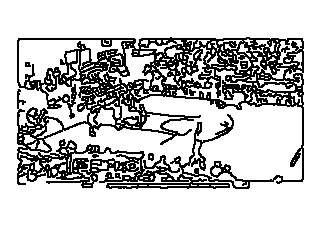
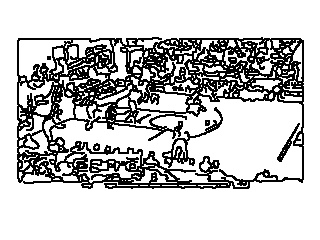
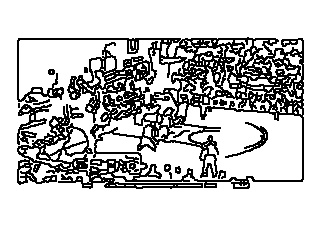

In [23]:
# Pick a deterministic test video.
sample = test_df.sort_values(["label", "clip_path"]).iloc[0]
ground_truth_label = sample['label']
clip_path = sample['clip_path']
video_path = os.path.join(dataset_path, clip_path)
video_extractor = VideoExtractor(video_path, privacy_preserving=True)
frames = video_extractor.extract_n_video_frames(n=no_frames)
video_extractor.display_frames(frames, height=180)


In [24]:
frames_list = [entry['frame_base64'] for entry in frames]

llm_insights = video_analyzer.video_chat(frames_list, transcription=None, system_message=system_message)

print(f"Predicted activity: {llm_insights['activity']}")
print(f"Actual activity: {ground_truth_label}")

Predicted activity: Basketball
Actual activity: Basketball


## Base versus Fine-Tuned Model Evaluation

The following code can be used to systematically evaluate the base model (GPT-4.1 in this case) against the fine-tuned model on the test dataset. This comparison helps quantify the improvements achieved through fine-tuning.

In [25]:
def classify_video(clip_path, video_analyzer, local_path=None, frames_per_video=1):
    """ Classify a single video and return its predicted activity. """

    uri = os.path.join(local_path, clip_path) if local_path else clip_path
    video_extractor = VideoExtractor(uri, privacy_preserving=True)
    frames = video_extractor.extract_n_video_frames(n=frames_per_video)
    frames_list = [entry['frame_base64'] for entry in frames]
    llm_insights = video_analyzer.video_chat(frames_list, transcription=None, system_message=system_message)
    return llm_insights['activity']


def classify_videos_in_df(test_df, video_analyzer, local_path, frames_per_video, column_name):
    """ Classify videos in a DataFrame and add predictions to a specified column. """
    tqdm.pandas(desc=f"Processing {column_name}")
    test_df[column_name] = test_df.progress_apply(
        lambda row: classify_video(
            clip_path=row['clip_path'],
            video_analyzer=video_analyzer,
            local_path=local_path,
            frames_per_video=frames_per_video
        ), axis=1
    )
    return test_df

In [26]:
# Base and fine-tuned model evaluation.
base_video_analyzer = VideoAnalyzer(client, base_deployment)
ft_video_analyzer = VideoAnalyzer(client, ft_deployment)

test_df = classify_videos_in_df(
    test_df=test_df,
    video_analyzer=base_video_analyzer,
    local_path=dataset_path,
    frames_per_video=no_frames,
    column_name='base_predicted_label',
)
test_df = classify_videos_in_df(
    test_df=test_df,
    video_analyzer=ft_video_analyzer,
    local_path=dataset_path,
    frames_per_video=no_frames,
    column_name='ft_predicted_label',
)

base_accuracy = float(
    (test_df["label"] == test_df["base_predicted_label"]).mean()
)
ft_accuracy = float(
    (test_df["label"] == test_df["ft_predicted_label"]).mean()
)
print({
    "base_accuracy": base_accuracy,
    "fine_tuned_accuracy": ft_accuracy,
    "accuracy_delta": ft_accuracy - base_accuracy,
})


Processing base_predicted_label:   0%|          | 0/15 [00:00<?, ?it/s]

Processing base_predicted_label:  13%|█▎        | 2/15 [00:02<00:14,  1.08s/it]

Processing base_predicted_label:  20%|██        | 3/15 [00:04<00:18,  1.56s/it]

Processing base_predicted_label:  27%|██▋       | 4/15 [00:06<00:18,  1.72s/it]

Processing base_predicted_label:  33%|███▎      | 5/15 [00:08<00:19,  1.91s/it]

...

Processing ft_predicted_label:  87%|████████▋ | 13/15 [02:44<00:35, 17.55s/it]

Processing ft_predicted_label:  93%|█████████▎| 14/15 [03:02<00:17, 17.92s/it]

Processing ft_predicted_label: 100%|██████████| 15/15 [03:21<00:00, 18.11s/it]

Processing ft_predicted_label: 100%|██████████| 15/15 [03:39<00:00, 14.65s/it]

{'base_accuracy': 0.7333333333333333, 'fine_tuned_accuracy': 0.7333333333333333, 'accuracy_delta': 0.0}


In [27]:
# Save evaluation results.
eval_results_path = (
    f"{project_name}-{version}-eval-results-{test_df.shape[0]}-entries.csv"
)
test_df.to_csv(eval_results_path, index=False)
print(eval_results_path)


action-recognition-global-vision-20261002-eval-results-15-entries.csv


In [28]:
# Reload the evaluation artifact produced by this run.
test_df = pd.read_csv(eval_results_path)
display(test_df.head())


,clip_name,clip_path,label,base_predicted_label,ft_predicted_label
0,v_Basketball_g15_c05,test/Basketball/v_Basketball_g15_c05.avi,Basketball,Basketball,Basketball
1,v_Basketball_g11_c02,test/Basketball/v_Basketball_g11_c02.avi,Basketball,Basketball,Basketball
2,v_BasketballDunk_g25_c02,test/Basketball/v_BasketballDunk_g25_c02.avi,Basketball,Basketball,Basketball
3,v_Basketball_g09_c01,test/Basketball/v_Basketball_g09_c01.avi,Basketball,Basketball,Basketball
4,v_Basketball_g08_c03,test/Basketball/v_Basketball_g08_c03.avi,Basketball,Basketball,Basketball


In [29]:
evaluator.compare_model_metrics(test_df)

C:\Data\AIP\fine-tuning\Demos\Video_FT_Action_Recognition\VideoFTTools.py:502: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


After comparing the performance of the base vs. fine-tuned model, we can further analyze the fine-tuning results by inspecting the **classification report** and **confusion matrix**.

In [30]:
y_true = test_df['label']
y_pred = test_df['ft_predicted_label']

# Generate classification report
report = classification_report(y_true, y_pred, output_dict=False, zero_division=True)
print(report)

              precision    recall  f1-score   support

  Basketball       0.71      1.00      0.83         5
 CricketShot       0.67      0.80      0.73         5
 TennisSwing       1.00      0.40      0.57         5

    accuracy                           0.73        15
   macro avg       0.79      0.73      0.71        15
weighted avg       0.79      0.73      0.71        15



In [31]:
evaluator = Evaluator()

evaluator.plot_confusion_matrix(y_true, y_pred)

C:\Data\AIP\fine-tuning\Demos\Video_FT_Action_Recognition\VideoFTTools.py:525: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [32]:
run_completed_at = pd.Timestamp.now("UTC").isoformat()
execution_summary = {
    "project_endpoint": project_endpoint,
    "foundry_sdk_version": package_version("azure-ai-projects"),
    "authentication": "DefaultAzureCredential",
    "base_model": base_model,
    "fine_tuning_job_id": ft_job.id,
    "fine_tuning_status": ft_job.status,
    "training_type": ft_job.to_dict().get("trainingType"),
    "fine_tuned_model": fine_tuned_model,
    "base_deployment": base_deployment,
    "fine_tuned_deployment": ft_deployment,
    "classes": list(top_classes),
    "train_examples": len(train_df),
    "validation_examples": len(val_df),
    "test_examples": len(test_df),
    "frames_per_video": no_frames,
    "base_accuracy": base_accuracy,
    "fine_tuned_accuracy": ft_accuracy,
    "accuracy_delta": ft_accuracy - base_accuracy,
    "job_status_history": job_status_history,
    "deployment_status_history": deployment_status_history,
    "base_deployment_details": base_deployment_result,
    "fine_tuned_deployment_details": ft_deployment_result,
    "privacy_preserving_frames": True,
    "started_at": run_started_at,
    "completed_at": run_completed_at,
}
with open("video-ft-execution-summary.json", "w", encoding="utf-8") as handle:
    json.dump(execution_summary, handle, indent=2)
print(json.dumps(execution_summary, indent=2))


{
  "project_endpoint": "https://koreacentral-prakharg-demo-2026.services.ai.azure.com/api/projects/koreacentral-prakharg-demo-2026",
  "foundry_sdk_version": "2.7.0",
  "authentication": "DefaultAzureCredential",
  "base_model": "gpt-4.1-2025-04-14",
  "fine_tuning_job_id": "ftjob-40024e60fc5d4fbe8378a52b3f6d74bd",
  "fine_tuning_status": "succeeded",
  "training_type": "globalStandard",
  "fine_tuned_model": "gpt-4.1-2025-04-14.ft-40024e60fc5d4fbe8378a52b3f6d74bd-ction-recognition-global-vision-20261002",
  "base_deployment": "action-recognition-global-vision-20261002-base",
  "fine_tuned_deployment": "action-recognition-global-vision-20261002-ft",
  "classes": [
    "Basketball",
    "CricketShot",
    "TennisSwing"
  ],
  "train_examples": 36,
  "validation_examples": 12,
  "test_examples": 15,
  "frames_per_video": 3,
  "base_accuracy": 0.7333333333333333,
  "fine_tuned_accuracy": 0.7333333333333333,
  "accuracy_delta": 0.0,
  "job_status_history": [
    {
      "time": "2026-10-0